In [1]:
from instruments.glass_displacement.GD import Displacement_Measurement
import os
import matplotlib.pyplot as plt
import numpy as np

control = Displacement_Measurement()

In [2]:
pths = []
pths.append(os.path.normpath('C:\\Users\\Sean Dunfield\\Documents\\Glass Displacement\\optimization1\\Indium\\01_Indium_GD_0.csv'))
pths.append(os.path.normpath('C:\\Users\\Sean Dunfield\\Documents\\Glass Displacement\\optimization1\\Sample2\\Sample2_GD_0.csv'))

c:\users\sean dunfield\documents\github\instruments\instruments\glass_displacement\GD.py:887: RuntimeWarning: invalid value encountered in power
  GG = (d2x**+d2y**2)**.5
c:\users\sean dunfield\documents\github\instruments\instruments\glass_displacement\GD.py:951: RuntimeWarning: invalid value encountered in divide
  concavity = np.diff(interp_heights, n=2)/np.diff(self.scribes, n=2)
c:\users\sean dunfield\documents\github\instruments\instruments\glass_displacement\GD.py:951: RuntimeWarning: divide by zero encountered in divide
  concavity = np.diff(interp_heights, n=2)/np.diff(self.scribes, n=2)


Text(0, 0.5, 'Height (mm)')

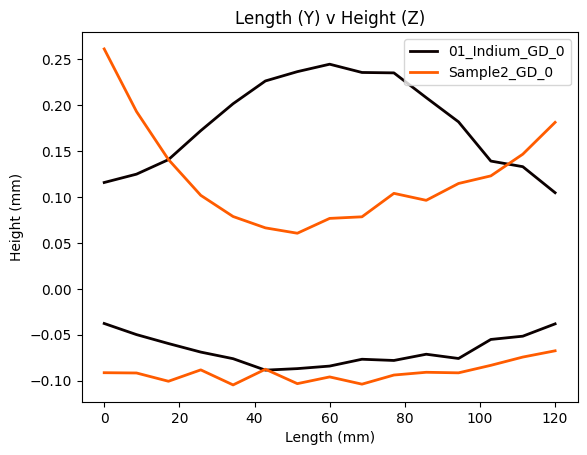

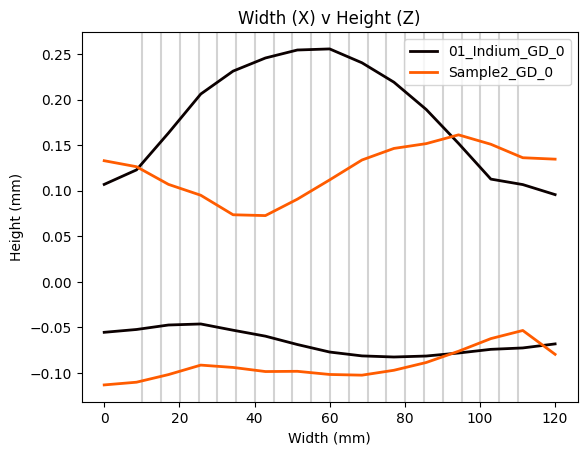

In [ ]:
# variables
fontsize = 8

# create figures for x and y
fig_x, ax_x = plt.subplots(1)
fig_y, ax_y = plt.subplots(1)

# load data and draw scribe lines
control.load_data(pths[0])
for scribe in control.locations['scribes']:
    ax_y.axvline(x= scribe, color = 'lightgrey')

# define color map
NUM_COLORS = len(pths)
cm = plt.get_cmap('hot') 
_colors = [cm(1.*i/NUM_COLORS) for i in range(NUM_COLORS)]
colors = []
for i in range(int(np.ceil(NUM_COLORS/2))):
    colors.append(_colors[i])
    colors.append(_colors[NUM_COLORS-i-1])


# iterate through each path and plot
for idx, path in enumerate(pths):

    control.load_data(path)
    name = (path.split(os.sep)[-1]).removesuffix('.csv')
    
    ax_x.plot(
            control.data_averages['front']['y'], 
            control.data_averages['front']['z(y)'], 
            linewidth =2,
            color = colors[idx],
            label = name 
            )
    ax_x.plot(
            control.data_averages['back']['y'], 
            control.data_averages['back']['z(y)'], 
            linewidth =2, 
            color = colors[idx],
            )

    ax_y.plot(
            control.data_averages['front']['x'], 
            control.data_averages['front']['z(x)'], 
            linewidth =2,
            color = colors[idx], 
            label = name
            )
    
    ax_y.plot(
            control.data_averages['back']['x'], 
            control.data_averages['back']['z(x)'], 
            color = colors[idx],
            linewidth =2, 
            )

ax_x.legend()
ax_y.legend()

ax_y.set_title('Width (X) v Height (Z)')
ax_y.set_xlabel('Width (mm)')
ax_y.set_ylabel('Height (mm)')

ax_x.set_title('Length (Y) v Height (Z)')
ax_x.set_xlabel('Length (mm)')
ax_x.set_ylabel('Height (mm)')

# add paths to save
# ax_x.figure.savefig()
# ax_x.figure.savefig()